In [4]:
from pathlib import Path
from typing import Optional
import sys
from tqdm import tqdm
import numpy as np
import pandas as pd
import spikeinterface as si 
import data_analysis.mea_analysis as mea
import data_analysis.loading_and_saving as load_save
import spikeinterface.extractors as se
import spikeinterface as si
from spikeinterface.qualitymetrics.misc_metrics import amplitude_cutoff
from spikeinterface.qualitymetrics import compute_isi_violations, compute_firing_rates
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [5]:
#get important file paths
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

In [6]:
# helper function to find the biggest .brw file in a folder: 
# They follow no locigal naming convention but the biggest one 
# is the one we want to use because that one is a sucessfull recording
def find_biggest_brw_in_folder(folder_path: Path) -> Optional[Path]:
    """
    Find the biggest .brw file in a folder. Returns the full path to the file.
    """
    biggest_file = None
    biggest_size = -1
    for file in folder_path.glob("*.brw"):
        if file.stat().st_size > biggest_size:
            biggest_file = file
            biggest_size = file.stat().st_size
    return biggest_file

In [ ]:
dicts = []
for i, row in tqdm(df_overview.iterrows()):
    print("-"*30)
    st_df, st, clu, best_cha_st, vectorized_map, amplitudes =  mea.get_stdf(row["folder_path"], return_amplitudes=True)
    print(f"clu 1: {clu.shape}")
    bin_path = row["bin_path"]
    original_folder_path = BRW_BASE_FOLDER / row["folder"]
    brw_path = find_biggest_brw_in_folder(folder_path=original_folder_path)
    recording = load_save.get_rec_obj(bin_path, brw_path=brw_path)
    recording = si.preprocessing.bandpass_filter(recording, freq_min=300, freq_max=6000)
    recording = si.preprocessing.common_reference(recording, reference="global", operator="median")
    results_folder = Path(row["folder_path"]) / "kilosort_output" / "sorter_output"
    
    sorting = se.read_kilosort(folder_path=Path(results_folder), keep_good_only=False)

    analyzer = si.create_sorting_analyzer(sorting=sorting,
                                      recording=recording,
                                      return_scaled=True,
                                      n_jobs=-1,
                                      format="memory",
                                      sparse=False,)
    
    isi_violations_ratio, isi_violations_count= compute_isi_violations(analyzer)
    frs = compute_firing_rates(analyzer)

    st_df["isi_violations_ratio"] = st_df["clu"].apply(lambda x: isi_violations_ratio[x])
    st_df["isi_violations_count"] = st_df["clu"].apply(lambda x: isi_violations_count[x])
    st_df["frs"] = st_df["clu"].apply(lambda x: frs[x])
    metrics_dict = {"unique_clusters":st_df["clu"].nunique(),
                "isi_violations_ratio":st_df["isi_violations_ratio"].mean()}
    
    #cut mua away
    st_df = st_df[st_df["frs"]>1] #roughly euqal to 600 spikes/recording (roughly because not all recordings are
                                  #exactly 600s long, some are are only >500s long)
    st_df = st_df[st_df["mua_labels"] == "good"]

    print(f"clu 2: {clu.shape}")
    assert amplitudes.shape == clu.shape, f"{amplitudes.shape}, {clu.shape}"
    cutoff_val = []
    for unit_id in st_df["clu"].unique():
        mask = (clu == unit_id)
        amplitudes_unit = amplitudes[mask]
        cutoff_val.append(amplitude_cutoff(amplitudes_unit, num_histogram_bins=150))
    st_df["amplitude_cutoff"] = cutoff_val

    metrics_dict["su_n"] = len(st_df)
    metrics_dict["su_isi_violations_ratio"] = st_df["isi_violations_ratio"].mean()
    metrics_dict["su_amplitude_cutoff"] = st_df["amplitude_cutoff"].mean()
    metrics_dict["frs"] = st_df["frs"].mean()
    dicts.append(metrics_dict)
    
    


0it [00:00, ?it/s]

------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------
clu 1: (318620,)


1it [00:05,  5.09s/it]

clu 2: (318620,)
------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
clu 1: (675651,)


2it [00:09,  4.86s/it]

clu 2: (675651,)
------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 580, disagreement: 0
Number of good clusters (Original): 107
Number of good clusters (Changed): 107
-------------------------------------------------------
clu 1: (1049040,)


3it [00:16,  5.58s/it]

clu 2: (1049040,)
------------------------------


In [7]:
df_overview[['n_unique_clusters', 'mean_isi_violations_ratio', 'n_su',
       'mean_su_isi_violations_ratio', 'mean_su_amplitude_cutoff', 'frs']] = pd.DataFrame(dicts)

In [8]:
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")

In [9]:
durs = [load_save.get_rec_obj(bin_path).get_duration() for bin_path in df_overview["bin_path_x"]]

In [ ]:
print(durs)

[599.9999881351795, 599.9999881351795, 599.9999881351795, 645.9419400939279, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 597.4462990806841, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795, 599.9999881351795]


In [11]:
num_animals = df_overview["animal_number"].nunique()
num_slices = df_overview["folder"].nunique()
print(f"Number of animals: {num_animals}, number of slices: {num_slices}")

Number of animals: 7, number of slices: 22


In [12]:
columns_to_save = ['folder', 
                   'analyzed',
       'mean_isi_violations_ratio',
       'n_su', 
       'mean_su_isi_violations_ratio', 
       'mean_su_amplitude_cutoff',
       'n_unique_clusters',
       'slice_number',
       'group',
       'preincub']

In [13]:
qms = [
       'mean_isi_violations_ratio',
       'n_su', 
       'mean_su_isi_violations_ratio', 
       'mean_su_amplitude_cutoff',
       'n_unique_clusters']

qm_df = df_overview.groupby("group")[qms].agg(["mean", "std"]).reset_index().T
#qm_df.T.to_excel(r"C:\Users\ferdi\OneDrive\Promotion\Paper MEA\grouped_q_metrics.xlsx")
qm_df.T

group mean_isi_violations_ratio            n_su             \
                              mean       std  mean        std   
0   Sham                  2.659749  1.184505  75.8    70.3575   
1  Tumor                  1.738329   0.97194  49.5  28.725978   

  mean_su_isi_violations_ratio           mean_su_amplitude_cutoff            \
                          mean       std                     mean       std   
0                     0.286553  0.060213                 0.027509  0.014283   
1                     0.238825  0.095904                 0.013007  0.010834   

  n_unique_clusters              
               mean         std  
0             552.3  219.716509  
1        502.583333  276.479971

In [14]:
mask_t = df_overview["group"] == "Tumor"
mask_s = df_overview["group"] == "Sham"
df_overview[columns_to_save][mask_t]["n_su"].describe(), df_overview[columns_to_save][mask_s]["n_su"].describe()

(count     12.000000
 mean      49.500000
 std       28.725978
 min       12.000000
 25%       31.750000
 50%       42.000000
 75%       58.000000
 max      107.000000
 Name: n_su, dtype: float64,
 count     10.0000
 mean      75.8000
 std       70.3575
 min       13.0000
 25%       36.5000
 50%       49.5000
 75%       88.0000
 max      256.0000
 Name: n_su, dtype: float64)

In [ ]:
df_overview["group"] = df_overview["group"].astype(str)
df_overview["n_su"] = df_overview["n_su"].astype(int)

In [17]:
res = mannwhitneyu(df_overview[mask_t]["n_su"], df_overview[mask_s]["n_su"])
print(f"Mann-Whitney U test: {res.statistic}, p-value: {res.pvalue}")

Mann-Whitney U test: 47.0, p-value: 0.40967914877229616


In [18]:
median_s = df_overview[mask_s]["n_su"].median()
median_t = df_overview[mask_t]["n_su"].median()
print(f"Median n_su Sham: {median_s}, Median n_su Tumor: {median_t}")

Median n_su Sham: 49.5, Median n_su Tumor: 42.0


In [19]:
df_overview[["folder","group"]]

,folder,group
0,8561_3,Tumor
1,8561_5,Tumor
2,8562_5,Sham
3,8562_7,Sham
4,8602_1,Tumor
5,8602_2,Tumor
6,8602_5,Tumor
7,8602_6,Tumor
8,8603_1,Tumor
9,8603_2,Tumor


In [20]:
import data_analysis.plotting as plotting

/tmp/ipykernel_61240/1516898639.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(x_ticks)
/tmp/ipykernel_61240/1516898639.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


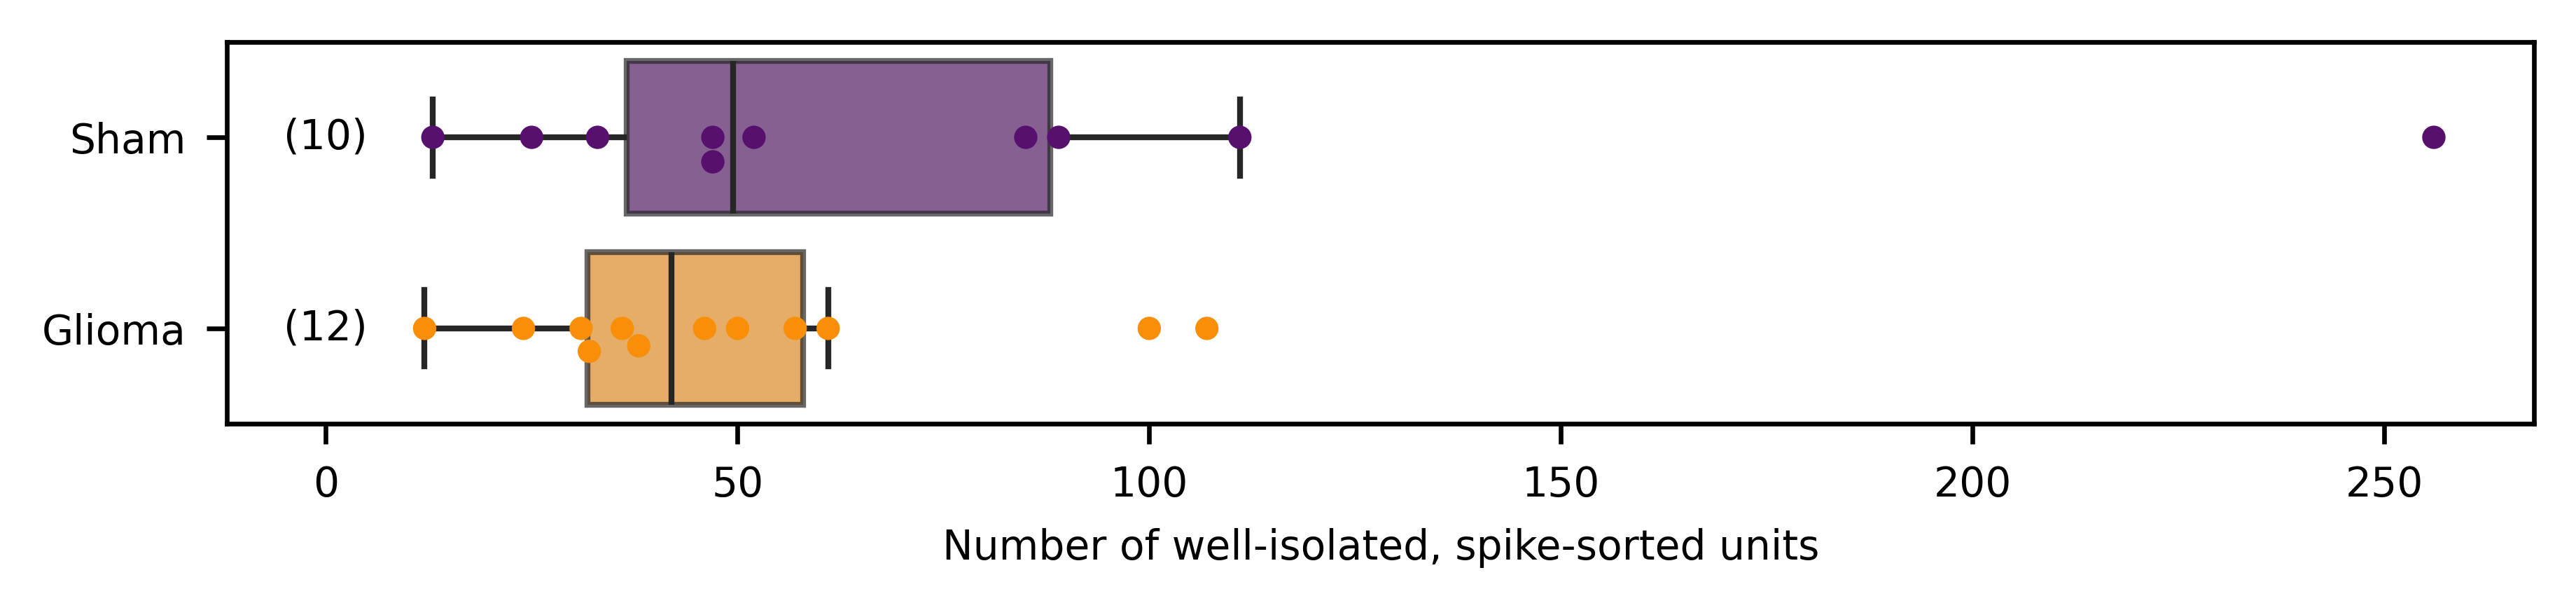

In [21]:
n_sham = sum(mask_s)
n_tumor = sum(mask_t)
colors = plotting.get_c_map_colors()
cm = 1/2.54
plt.rcParams.update({'font.size': 7})
fig, ax = plt.subplots(1, 1, figsize=(18*cm, 3*cm), dpi=600)
column = "n_su"
df_overview.sort_values(by="group", ascending=True, inplace=True)

sns.boxplot(y="group", x=column, data=df_overview, ax=ax, 
            palette=[colors[1],colors[3]], hue="group", #width=0.4, 
            fliersize=0, zorder=0, boxprops={'alpha': 0.7}, orient="h")
sns.swarmplot(y="group", x=column, data=df_overview, hue="group",ax=ax, palette=[colors[1],colors[3]], dodge=False,s=4)

x_ticks = ["Sham", "Glioma"]
ax.set_yticklabels(x_ticks)
ax.set_yticks([0, 1])
ax.set_ylabel("")
ax.set_xlabel("Number of well-isolated, spike-sorted units")

x_level = -0
ax.text(x_level, 0, f"({n_sham})", ha='center', va='center')
ax.text(x_level, 1, f"({n_tumor})", ha='center', va='center')
ax.set_xlim(-12, None)

plt.legend().remove()

plt.savefig("plots/figure_qm.png", dpi=600, bbox_inches='tight')
plt.show()